# PAID MOBILE GAME LAUNCH STRATEGY ANALYSIS

## Business Context

Stakeholder là một mobile game studio đang chuẩn bị ra mắt một **game Paid / Premium** trên App Store.

Bài phân tích tập trung trả lời:

1. Nếu ra mắt một game Paid, nên ưu tiên genre nào?
2. Genre nào có dấu hiệu người dùng sẵn sàng trả tiền?
3. Paid game thành công thường có đặc điểm gì về rating, rating count, giá bán, localization?
4. Mức giá nào có tín hiệu tốt trong giai đoạn gần nhất?
5. Nên benchmark game/developer nào trong nhóm Paid?
6. Paid game nên đi theo hướng premium/niche/offline/story game hay hướng game có thương hiệu mạnh?

## Final Business Decision

Kết quả phân tích sẽ hỗ trợ stakeholder ra quyết định về:

- Genre ưu tiên để phát triển game Paid.
- Price range phù hợp cho launch.
- Nhóm game/developer nên benchmark.
- Chiến lược localization phù hợp với Paid game.
- Launch strategy phù hợp với mô hình premium.

# 1. Business Question Clarification

## Stakeholder muốn biết điều gì?

Stakeholder muốn biết nếu studio ra mắt một game Paid thì nên chọn genre, mức giá và benchmark như thế nào để tăng khả năng người dùng sẵn sàng trả tiền.

## Quyết định kinh doanh cần đưa ra

Sau phân tích, stakeholder cần quyết định:

1. Nên ưu tiên genre nào cho game Paid?
2. Nên định giá launch trong khoảng nào?
3. Nên học hỏi benchmark từ game/developer nào?
4. Localization nên đầu tư rộng hay chọn lọc?
5. Launch strategy nên đi theo hướng premium/niche/offline/story game hay dựa vào thương hiệu mạnh?

## SMART Objective

Trong phạm vi dataset App Store Games giai đoạn 2008–2019, xác định các genre, price range, game và developer Paid có tín hiệu tốt nhất trong 3 năm gần nhất của dataset, dựa trên weighted rating, rating count, rating velocity, paid revenue proxy và localization proxy, nhằm hỗ trợ định hướng launch game Paid.

## North Star Metric

Vì Paid game yêu cầu người chơi trả tiền ngay từ đầu, North Star Metric phù hợp là:

> Paid Market Confidence

Tức là mức độ thị trường cho thấy người dùng sẵn sàng trả tiền cho một game có chất lượng đáng tin cậy.

## Proxy Metrics

Dataset không có sales, revenue, conversion rate, refund rate, retention nên cần dùng proxy:

| Proxy Metric | Ý nghĩa business | Giới hạn |
|---|---|---|
| weighted_rating | Proxy cho chất lượng đáng tin cậy | Vẫn chỉ dựa trên review |
| rating_count | Proxy cho market traction | Không phải số lượt mua thật |
| rating_velocity | Proxy cho tốc độ tạo traction | Không có lịch sử rating theo tháng/năm |
| price_usd | Giá bán app | Không biết lịch sử đổi giá |
| paid_revenue_proxy | Proxy rất thô cho commercial potential | Không phải doanh thu thật |
| language_count | Proxy cho localization/global reach | Không biết doanh thu theo quốc gia |
| genre_freshness_rate | Genre còn active gần đây không | Không đo trực tiếp demand |

# 2. Scope & Limitation

## Đơn vị phân tích

Mỗi dòng trong dataset đại diện cho một app/game trên App Store.

## Phạm vi thời gian

Dataset có dữ liệu release date từ 2008 đến 2019.

Tuy nhiên, khi đưa recommendation cho game mới, bài phân tích sẽ ưu tiên **3 năm gần nhất trong dataset**, thường là 2017–2019.

## Scope chính

Chỉ phân tích game Paid:

`Price per App (USD) > 0`

Free game chỉ được dùng để kiểm tra tổng quan ban đầu, không dùng làm nhánh recommendation chính.

## Dataset có thể trả lời

Dataset có thể hỗ trợ trả lời:

- Paid game nào có weighted rating tốt?
- Paid game nào có rating count cao?
- Paid game nào có rating velocity cao?
- Price range nào có tín hiệu tốt gần đây?
- Genre nào còn active trong nhóm Paid?
- Genre nào có paid revenue proxy tốt?
- Developer nào có Paid game đáng benchmark?
- Nhóm Paid game traction cao thường hỗ trợ bao nhiêu ngôn ngữ?

## Dataset không thể trả lời trực tiếp

Dataset không có:

- Actual sales
- Revenue thật
- Conversion rate
- Refund rate
- IAP revenue
- Ads revenue
- Retention
- DAU/MAU
- Marketing spend
- Rating count history theo từng tháng/năm
- Lịch sử thay đổi giá theo thời gian

Vì vậy các metric như `paid_revenue_proxy`, `rating_velocity`, `paid_success_score`, `paid_genre_attractiveness_score` chỉ là proxy hỗ trợ ra quyết định, không phải kết luận tuyệt đối.

# 3. Import Library & Load Data

Cell này import thư viện và load file `App Store Games.xlsx`.

Nếu chạy trên Google Colab, hãy upload file Excel khi được yêu cầu.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

file_path = "/content/App Store Games.xlsx"

if not os.path.exists(file_path):
    from google.colab import files
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]

df_raw = pd.read_excel(file_path, sheet_name="App Store Games")

print("Dataset shape:", df_raw.shape)
display(df_raw.head())

Dataset shape: (17007, 16)


,App URL,App ID,Name,Subtitle,Icon URL,Average User Rating,User Rating Count,Price per App (USD),Description,Developer,Age Rating,Languages,Size in Bytes,Primary Genre,Genres,Release Date
0,https://apps.apple.com/us/app/sudoku/id284921427,284921427,Sudoku,NaN,https://is2-ssl.mzstatic.com/image/thumb/Purple127/v4/7d/23/c6/7d23c660-aba8-308a-05c0-19385a377c0e/source/512x512bb...,4.0,3553.0,2.99,"Join over 21,000,000 of our fans and download one of our Sudoku games today!\n\nMakers of the Best Sudoku Game of 20...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT, RU, ZH, ES, SV, ZH",15853568.0,Games,"Games, Strategy, Puzzle",2008-07-11
1,https://apps.apple.com/us/app/reversi/id284926400,284926400,Reversi,NaN,https://is4-ssl.mzstatic.com/image/thumb/Purple128/v4/f7/e8/10/f7e810c8-72b4-cd85-e2d3-fbcb1e3ef381/source/512x512bb...,3.5,284.0,1.99,"The classic game of Reversi, also known as Othello, is a much-loved strategy board game. It is often described as ta...",Kiss The Machine,4+,EN,12328960.0,Games,"Games, Strategy, Board",2008-07-11
2,https://apps.apple.com/us/app/morocco/id284946595,284946595,Morocco,NaN,https://is5-ssl.mzstatic.com/image/thumb/Purple118/v4/98/b2/41/98b241cc-29b7-5f67-0060-1e030f35562f/source/512x512bb...,3.0,8376.0,0.00,Play the classic strategy game Othello (also known as Reversi) on your iPhone or iPod Touch. The object is to finish...,Bayou Games,4+,EN,674816.0,Games,"Games, Board, Strategy",2008-07-11
3,https://apps.apple.com/us/app/sudoku-free/id285755462,285755462,Sudoku (Free),NaN,https://is3-ssl.mzstatic.com/image/thumb/Purple117/v4/64/da/aa/64daaaa4-40b5-9e9f-9d60-b936b5d2f3ca/source/512x512bb...,3.5,190394.0,0.00,"Top 100 free app for over a year.\nRated ""Best Sudoku Game of the Year"" by Apple.\nRated #9 Game of the Year by Appl...",Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT, RU, ZH, ES, SV, ZH",21552128.0,Games,"Games, Strategy, Puzzle",2008-07-23
4,https://apps.apple.com/us/app/senet-deluxe/id285831220,285831220,Senet Deluxe,NaN,https://is1-ssl.mzstatic.com/image/thumb/Purple118/v4/ab/2d/cf/ab2dcfe6-2178-6f74-2d42-0b6db66fc7e0/source/512x512bb...,3.5,28.0,2.99,"""Senet Deluxe - The Ancient Game of Life and Afterlife\n\nSenet is an ancient Egyptian race game and the predecessor...",RoGame Software,4+,"DA, NL, EN, FR, DE, EL, IT, JA, KO, NO, PT, RU, ZH, ES, SV",34689024.0,Games,"Games, Strategy, Board, Education",2008-07-18


# 4. Select Necessary Columns

Chỉ chọn các cột cần thiết cho business request.

| Cột | Lý do sử dụng |
|---|---|
| App ID | Xác định app unique, kiểm tra duplicate |
| Name | Tên game để benchmark |
| Average User Rating | Chất lượng rating ban đầu |
| User Rating Count | Proxy cho popularity/traction |
| Price per App (USD) | Lọc game Paid và phân tích price range |
| Developer | Benchmark developer |
| Age Rating | Hiểu positioning/tệp người chơi |
| Languages | Phân tích localization |
| Size in Bytes | Đánh giá friction tải app |
| Primary Genre | Genre chính nếu cần |
| Genres | Tách genre game cụ thể |
| Release Date | Phân tích thời gian, freshness, rating velocity |

In [2]:
rename_map = {
    "App ID": "app_id",
    "Name": "name",
    "Average User Rating": "avg_rating",
    "User Rating Count": "rating_count",
    "Price per App (USD)": "price_usd",
    "Developer": "developer",
    "Age Rating": "age_rating",
    "Languages": "languages",
    "Size in Bytes": "size_bytes",
    "Primary Genre": "primary_genre",
    "Genres": "genres",
    "Release Date": "release_date"
}

data = df_raw.rename(columns=rename_map).copy()

selected_cols = [
    "app_id",
    "name",
    "avg_rating",
    "rating_count",
    "price_usd",
    "developer",
    "age_rating",
    "languages",
    "size_bytes",
    "primary_genre",
    "genres",
    "release_date"
]

data = data[selected_cols].copy()

display(data.head())

,app_id,name,avg_rating,rating_count,price_usd,developer,age_rating,languages,size_bytes,primary_genre,genres,release_date
0,284921427,Sudoku,4.0,3553.0,2.99,Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT, RU, ZH, ES, SV, ZH",15853568.0,Games,"Games, Strategy, Puzzle",2008-07-11
1,284926400,Reversi,3.5,284.0,1.99,Kiss The Machine,4+,EN,12328960.0,Games,"Games, Strategy, Board",2008-07-11
2,284946595,Morocco,3.0,8376.0,0.00,Bayou Games,4+,EN,674816.0,Games,"Games, Board, Strategy",2008-07-11
3,285755462,Sudoku (Free),3.5,190394.0,0.00,Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT, RU, ZH, ES, SV, ZH",21552128.0,Games,"Games, Strategy, Puzzle",2008-07-23
4,285831220,Senet Deluxe,3.5,28.0,2.99,RoGame Software,4+,"DA, NL, EN, FR, DE, EL, IT, JA, KO, NO, PT, RU, ZH, ES, SV",34689024.0,Games,"Games, Strategy, Board, Education",2008-07-18


# 5. Analysis Plan

Trước khi code phân tích, cần lập plan để đảm bảo mỗi bảng/biểu đồ đều phục vụ một business question.

In [3]:
analysis_plan = pd.DataFrame({
    "business_question": [
        "Thị trường Paid game thay đổi như thế nào theo thời gian?",
        "Price range nào có tín hiệu tốt trong giai đoạn gần nhất?",
        "Genre nào phù hợp nhất để launch Paid game?",
        "Genre nào còn active trong nhóm Paid?",
        "Paid game nào có rating đáng tin cậy?",
        "Paid game nào có commercial potential tốt?",
        "Paid game nào nên benchmark?",
        "Localization nên làm rộng hay chọn lọc?",
        "Developer nào nên benchmark?",
        "Game cụ thể nào nên lấy làm case study?",
        "Stakeholder nên hành động gì tiếp theo?"
    ],
    "metric_formula": [
        "paid_app_count, total_rating_count, median_price theo release_year",
        "price_group summary: app_count, weighted_rating, rating_count, revenue_proxy",
        "paid_genre_attractiveness_score",
        "genre_freshness_rate = recent_paid_apps / total_paid_apps",
        "Bayesian weighted_rating",
        "paid_revenue_proxy = price_usd * rating_count",
        "paid_success_score",
        "language_count, top languages among high-traction Paid games",
        "developer_benchmark_score",
        "Top game theo paid_success_score",
        "Top 2–3 actions dựa trên output"
    ],
    "needed_columns": [
        "price_usd, release_date, rating_count",
        "price_usd, rating_count, avg_rating",
        "genres, release_date, rating_count, avg_rating, price_usd, languages",
        "genres, release_date, app_id",
        "avg_rating, rating_count",
        "price_usd, rating_count",
        "name, developer, rating_count, weighted_rating, rating_velocity, price_usd",
        "languages, rating_velocity",
        "developer, rating_count, weighted_rating, rating_velocity, price_usd",
        "name, developer, genre, rating_count, price_usd, languages",
        "All final outputs"
    ],
    "expected_output": [
        "1 summary table + 1 line chart",
        "1 price range table + 1 bar chart",
        "1 genre ranking table + 1 bar chart",
        "1 freshness table",
        "Weighted rating used inside ranking",
        "Revenue proxy used inside ranking",
        "1 benchmark game table",
        "1 localization table + 1 language table",
        "1 developer benchmark table",
        "1 case study table",
        "Markdown recommendation"
    ]
})

display(analysis_plan)

,business_question,metric_formula,needed_columns,expected_output
0,Thị trường Paid game thay đổi như thế nào theo thời gian?,"paid_app_count, total_rating_count, median_price theo release_year","price_usd, release_date, rating_count",1 summary table + 1 line chart
1,Price range nào có tín hiệu tốt trong giai đoạn gần nhất?,"price_group summary: app_count, weighted_rating, rating_count, revenue_proxy","price_usd, rating_count, avg_rating",1 price range table + 1 bar chart
2,Genre nào phù hợp nhất để launch Paid game?,paid_genre_attractiveness_score,"genres, release_date, rating_count, avg_rating, price_usd, languages",1 genre ranking table + 1 bar chart
3,Genre nào còn active trong nhóm Paid?,genre_freshness_rate = recent_paid_apps / total_paid_apps,"genres, release_date, app_id",1 freshness table
4,Paid game nào có rating đáng tin cậy?,Bayesian weighted_rating,"avg_rating, rating_count",Weighted rating used inside ranking
5,Paid game nào có commercial potential tốt?,paid_revenue_proxy = price_usd * rating_count,"price_usd, rating_count",Revenue proxy used inside ranking
6,Paid game nào nên benchmark?,paid_success_score,"name, developer, rating_count, weighted_rating, rating_velocity, price_usd",1 benchmark game table
7,Localization nên làm rộng hay chọn lọc?,"language_count, top languages among high-traction Paid games","languages, rating_velocity",1 localization table + 1 language table
8,Developer nào nên benchmark?,developer_benchmark_score,"developer, rating_count, weighted_rating, rating_velocity, price_usd",1 developer benchmark table
9,Game cụ thể nào nên lấy làm case study?,Top game theo paid_success_score,"name, developer, genre, rating_count, price_usd, languages",1 case study table


# 6. Data Cleaning & Feature Engineering

Bước này chỉ làm sạch dữ liệu ở mức đủ dùng.

Các xử lý chính:

1. Chuyển numeric columns về dạng số.
2. Chuyển release_date về datetime.
3. Xóa duplicate theo app_id.
4. Tạo release_year.
5. Tạo price_type để lọc Paid game.
6. Tạo game_genre từ Genres hoặc Primary Genre.
7. Tạo language_count từ Languages.
8. Tạo size_mb từ Size in Bytes.
9. Tạo price_group để phân tích mức giá.

Không preprocessing quá mức vì mục tiêu là phân tích để ra quyết định, không phải xây model.

In [4]:
# Convert numeric columns
numeric_cols = ["avg_rating", "rating_count", "price_usd", "size_bytes"]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Convert datetime robustly
if pd.api.types.is_numeric_dtype(data["release_date"]):
    data["release_date"] = pd.to_datetime(
        data["release_date"],
        unit="D",
        origin="1899-12-30",
        errors="coerce"
    )
else:
    data["release_date"] = pd.to_datetime(data["release_date"], errors="coerce")

# Data quality before dedup
before_dedup = len(data)
duplicate_app_count = data["app_id"].duplicated().sum()

# Remove duplicate app_id
data = data.drop_duplicates(subset=["app_id"]).copy()

# Remove rows missing key fields required for scope
data = data.dropna(subset=["app_id", "price_usd", "release_date"]).copy()

# Create release year
data["release_year"] = data["release_date"].dt.year.astype(int)

# Create price type
data["price_type"] = np.where(data["price_usd"].eq(0), "Free", "Paid")

# Parse list-like text columns
def parse_list(x):
    if pd.isna(x):
        return []
    return [i.strip() for i in str(x).split(",") if i.strip()]

GAME_GENRES = {
    "Action", "Adventure", "Arcade", "Board", "Card", "Casino", "Casual",
    "Family", "Music", "Puzzle", "Racing", "Role Playing", "Simulation",
    "Sports", "Strategy", "Trivia", "Word"
}

def extract_game_genre(genres_text, primary_genre):
    genre_list = parse_list(genres_text)

    # Ưu tiên genre game cụ thể trong cột Genres
    for g in genre_list:
        if g in GAME_GENRES:
            return g

    # Nếu không thấy, dùng Primary Genre nếu nằm trong game genre
    if pd.notna(primary_genre) and primary_genre in GAME_GENRES:
        return primary_genre

    # Nếu vẫn không có, lấy genre không quá generic
    for g in genre_list:
        if g not in ["Games", "Entertainment"]:
            return g

    return np.nan

def parse_languages(x):
    if pd.isna(x):
        return []
    return sorted(set([i.strip().upper() for i in str(x).split(",") if i.strip()]))

def assign_price_group(price):
    if pd.isna(price):
        return np.nan
    elif price <= 0:
        return "Free"
    elif price <= 0.99:
        return "$0.99"
    elif price <= 1.99:
        return "$1.99"
    elif price <= 2.99:
        return "$2.99"
    elif price <= 4.99:
        return "$3.99-$4.99"
    elif price <= 9.99:
        return "$5-$9.99"
    else:
        return "$10+"

data["game_genre"] = data.apply(
    lambda row: extract_game_genre(row["genres"], row["primary_genre"]),
    axis=1
)

data["language_list"] = data["languages"].apply(parse_languages)
data["language_count"] = data["language_list"].apply(len)
data["has_english"] = data["language_list"].apply(lambda x: "EN" in x)

data["size_mb"] = data["size_bytes"] / (1024 ** 2)
data["price_group"] = data["price_usd"].apply(assign_price_group)

display(data.head())

,app_id,name,avg_rating,rating_count,price_usd,developer,age_rating,languages,size_bytes,primary_genre,genres,release_date,release_year,price_type,game_genre,language_list,language_count,has_english,size_mb,price_group
0,284921427,Sudoku,4.0,3553.0,2.99,Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT, RU, ZH, ES, SV, ZH",15853568.0,Games,"Games, Strategy, Puzzle",2008-07-11,2008,Paid,Strategy,"[DA, DE, EN, ES, FI, FR, IT, JA, KO, NB, NL, PL, PT, RU, SV, ZH]",16,True,15.119141,$2.99
1,284926400,Reversi,3.5,284.0,1.99,Kiss The Machine,4+,EN,12328960.0,Games,"Games, Strategy, Board",2008-07-11,2008,Paid,Strategy,[EN],1,True,11.757812,$1.99
2,284946595,Morocco,3.0,8376.0,0.00,Bayou Games,4+,EN,674816.0,Games,"Games, Board, Strategy",2008-07-11,2008,Free,Board,[EN],1,True,0.643555,Free
3,285755462,Sudoku (Free),3.5,190394.0,0.00,Mighty Mighty Good Games,4+,"DA, NL, EN, FI, FR, DE, IT, JA, KO, NB, PL, PT, RU, ZH, ES, SV, ZH",21552128.0,Games,"Games, Strategy, Puzzle",2008-07-23,2008,Free,Strategy,"[DA, DE, EN, ES, FI, FR, IT, JA, KO, NB, NL, PL, PT, RU, SV, ZH]",16,True,20.553711,Free
4,285831220,Senet Deluxe,3.5,28.0,2.99,RoGame Software,4+,"DA, NL, EN, FR, DE, EL, IT, JA, KO, NO, PT, RU, ZH, ES, SV",34689024.0,Games,"Games, Strategy, Board, Education",2008-07-18,2008,Paid,Strategy,"[DA, DE, EL, EN, ES, FR, IT, JA, KO, NL, NO, PT, RU, SV, ZH]",15,True,33.082031,$2.99


# 7. Data Quality Check

Kiểm tra nhanh chất lượng dữ liệu sau khi cleaning:

- Số dòng còn lại
- Duplicate theo app_id
- Missing ở các cột quan trọng
- Khoảng thời gian dataset
- Tỷ trọng Free/Paid

Paid game là scope chính, nhưng vẫn kiểm tra Free/Paid để xác nhận dữ liệu ban đầu.

In [5]:
quality_check = pd.DataFrame({
    "metric": [
        "rows_before_dedup",
        "duplicate_app_id_before_cleaning",
        "rows_after_cleaning",
        "unique_apps",
        "min_release_year",
        "max_release_year",
        "missing_avg_rating",
        "missing_rating_count",
        "missing_game_genre",
        "missing_languages"
    ],
    "value": [
        before_dedup,
        duplicate_app_count,
        len(data),
        data["app_id"].nunique(),
        data["release_year"].min(),
        data["release_year"].max(),
        data["avg_rating"].isna().sum(),
        data["rating_count"].isna().sum(),
        data["game_genre"].isna().sum(),
        data["languages"].isna().sum()
    ]
})

display(quality_check)

price_type_summary = (
    data.groupby("price_type")
    .agg(
        app_count=("app_id", "nunique"),
        avg_rating=("avg_rating", "mean"),
        total_rating_count=("rating_count", "sum"),
        median_rating_count=("rating_count", "median"),
        median_price=("price_usd", "median")
    )
    .reset_index()
)

price_type_summary["app_share"] = price_type_summary["app_count"] / price_type_summary["app_count"].sum()

display(price_type_summary)

,metric,value
0,rows_before_dedup,17007
1,duplicate_app_id_before_cleaning,160
2,rows_after_cleaning,16847
3,unique_apps,16847
4,min_release_year,2008
5,max_release_year,2019
6,missing_avg_rating,9359
7,missing_rating_count,9359
8,missing_game_genre,0
9,missing_languages,0


,price_type,app_count,avg_rating,total_rating_count,median_rating_count,median_price,app_share
0,Free,14108,4.072500,22557226.0,42.0,0.00,0.837419
1,Paid,2739,4.008614,2199935.0,68.0,1.99,0.162581


# 8. Filter Paid Games & Recent Paid Games

Từ bước này, phân tích chính chỉ dùng game Paid.

Ta tạo 2 dataset:

1. `paid_data`: toàn bộ game Paid.
2. `recent_paid`: game Paid trong 3 năm gần nhất của dataset.

Lý do dùng giai đoạn gần nhất:

Dataset kéo dài từ 2008 đến 2019. Nếu dùng toàn bộ lịch sử để recommend giá và genre cho game mới, kết luận có thể bị ảnh hưởng bởi trend cũ, lạm phát và thay đổi hành vi người dùng theo thời gian.

In [6]:
paid_data = data[data["price_type"].eq("Paid")].copy()

latest_year = int(paid_data["release_year"].max())
recent_start_year = latest_year - 2

recent_paid = paid_data[
    paid_data["release_year"].between(recent_start_year, latest_year)
].copy()

display(Markdown(f"""
## Paid Game Scope

- Latest year in Paid dataset: **{latest_year}**
- Recent analysis window: **{recent_start_year}–{latest_year}**
- Total Paid games: **{len(paid_data):,}**
- Recent Paid games: **{len(recent_paid):,}**
"""))

display(recent_paid.head())


## Paid Game Scope

- Latest year in Paid dataset: **2019**
- Recent analysis window: **2017–2019**
- Total Paid games: **2,739**
- Recent Paid games: **912**


,app_id,name,avg_rating,rating_count,price_usd,developer,age_rating,languages,size_bytes,primary_genre,genres,release_date,release_year,price_type,game_genre,language_list,language_count,has_english,size_mb,price_group
1386,530090434,7 Wonders,4.0,230.0,4.99,Repos Production,4+,"NL, EN, FR, DE, IT, PL, ES",521525248.0,Games,"Games, Strategy, Entertainment, Card",2017-11-13,2017,Paid,Strategy,"[DE, EN, ES, FR, IT, NL, PL]",7,True,497.365234,$3.99-$4.99
2920,749488884,Element - RTS,4.5,201.0,4.99,Flightless,9+,"ZH, NL, EN, FR, DE, ID, IT, JA, KO, NB, PL, PT, RU, ZH, ES, SV, TH, ZH, TR",145458176.0,Games,"Games, Action, Strategy",2018-10-18,2018,Paid,Action,"[DE, EN, ES, FR, ID, IT, JA, KO, NB, NL, PL, PT, RU, SV, TH, TR, ZH]",17,True,138.719727,$3.99-$4.99
4581,916190049,Turmoil,4.5,153.0,5.99,Gamious B.V.,4+,EN,91333632.0,Games,"Games, Strategy, Simulation",2017-02-22,2017,Paid,Strategy,[EN],1,True,87.102539,$5-$9.99
4868,934012726,Six Ages: Ride Like the Wind,5.0,495.0,9.99,"A Sharp, LLC",12+,EN,766313472.0,Games,"Games, Role Playing, Strategy, Entertainment",2018-07-03,2018,Paid,Role Playing,[EN],1,True,730.813477,$5-$9.99
4964,942293005,Epic Little War Game,4.0,91.0,4.99,Rubicon,12+,EN,126474240.0,Games,"Games, Strategy, Entertainment, Action",2017-05-31,2017,Paid,Strategy,[EN],1,True,120.615234,$3.99-$4.99


# 9. Create Core Paid Game KPIs

## 9.1 Weighted Rating

Không nên dùng Average User Rating đơn thuần để xếp hạng game.

Ví dụ:

- Game A: 5 sao nhưng chỉ có 10 reviews.
- Game B: 4.5 sao nhưng có 100,000 reviews.

Game B đáng tin hơn Game A.

Vì vậy ta dùng Bayesian Weighted Rating:

`weighted_rating = (v / (v + m)) * R + (m / (v + m)) * C`

Trong đó:

- `R`: average rating của game
- `v`: rating count của game
- `C`: average rating trung bình của Paid games
- `m`: ngưỡng rating count tối thiểu, lấy theo percentile 75%

## 9.2 Rating Velocity

Dataset không có lịch sử rating count theo từng tháng/năm, nên không thể tính growth thật.

Ta dùng proxy:

`rating_velocity = rating_count / game_age_years`

Ý nghĩa:

> Trung bình mỗi năm game tạo được bao nhiêu rating count.

## 9.3 Paid Revenue Proxy

`paid_revenue_proxy = price_usd * rating_count`

Đây **không phải doanh thu thật**.

Nó chỉ là proxy rất thô để xem game nào vừa có giá bán vừa có rating count tương đối tốt.

In [7]:
rated_paid_mask = (
    paid_data["rating_count"].fillna(0).gt(0)
    & paid_data["avg_rating"].notna()
)

C = paid_data.loc[rated_paid_mask, "avg_rating"].mean()
m = paid_data.loc[rated_paid_mask, "rating_count"].quantile(0.75)
m = max(1, m)

def add_paid_game_kpis(df, C, m, latest_year):
    df = df.copy()

    votes = df["rating_count"].fillna(0)
    rating = df["avg_rating"].fillna(C)

    df["weighted_rating"] = (
        (votes / (votes + m)) * rating
        + (m / (votes + m)) * C
    )

    df["game_age_years"] = (latest_year - df["release_year"] + 1).clip(lower=1)
    df["rating_velocity"] = votes / df["game_age_years"]
    df["paid_revenue_proxy"] = df["price_usd"].fillna(0) * votes

    return df

paid_data = add_paid_game_kpis(paid_data, C, m, latest_year)
recent_paid = add_paid_game_kpis(recent_paid, C, m, latest_year)

# Tạo subset chỉ gồm game có rating_count > 0 để phân tích traction
rated_recent_paid = recent_paid[recent_paid["rating_count"].fillna(0).gt(0)].copy()

display(Markdown(f"""
## KPI Parameters

- Market average rating for Paid games, C: **{C:.2f}**
- Minimum rating count threshold, m: **{m:,.0f}**
- Recent Paid games with rating count > 0: **{len(rated_recent_paid):,}**
"""))

display(
    rated_recent_paid[
        [
            "name",
            "developer",
            "game_genre",
            "release_year",
            "price_usd",
            "price_group",
            "avg_rating",
            "rating_count",
            "weighted_rating",
            "rating_velocity",
            "paid_revenue_proxy",
            "language_count"
        ]
    ].head()
)


## KPI Parameters

- Market average rating for Paid games, C: **4.01**
- Minimum rating count threshold, m: **418**
- Recent Paid games with rating count > 0: **233**


,name,developer,game_genre,release_year,price_usd,price_group,avg_rating,rating_count,weighted_rating,rating_velocity,paid_revenue_proxy,language_count
1386,7 Wonders,Repos Production,Strategy,2017,4.99,$3.99-$4.99,4.0,230.0,4.005556,76.666667,1147.70,7
2920,Element - RTS,Flightless,Action,2018,4.99,$3.99-$4.99,4.5,201.0,4.168175,100.500000,1002.99,17
4581,Turmoil,Gamious B.V.,Strategy,2017,5.99,$5-$9.99,4.5,153.0,4.140281,51.000000,916.47,1
4868,Six Ages: Ride Like the Wind,"A Sharp, LLC",Role Playing,2018,9.99,$5-$9.99,5.0,495.0,4.546112,247.500000,4945.05,1
4964,Epic Little War Game,Rubicon,Strategy,2017,4.99,$3.99-$4.99,4.0,91.0,4.007074,30.333333,454.09,1


# 10. Output 1 — Paid Game Market Overview

## Business Question

Thị trường Paid game thay đổi như thế nào trong giai đoạn gần nhất?

## Metric

- `paid_app_count`: số game Paid phát hành theo năm.
- `rated_paid_app_count`: số game Paid có rating.
- `median_price`: giá median.
- `total_rating_count`: tổng rating count.
- `median_rating_velocity`: median rating velocity.

## Business Meaning

Với Paid game, nếu số lượng app mới giảm hoặc rating count thấp, điều đó có thể cho thấy thị trường khó hơn hoặc người dùng ít sẵn sàng trả tiền hơn.

Tuy nhiên, cần kết hợp thêm price range, genre và benchmark trước khi đưa recommendation.

,release_year,paid_app_count,median_price,total_rating_count,rated_paid_app_count,median_rating_velocity,median_weighted_rating,median_paid_revenue_proxy
0,2017,441,1.99,65200.0,114,9.333333,4.008472,90.915
1,2018,281,1.99,95692.0,76,16.750000,4.020332,117.265
2,2019,190,1.99,10060.0,43,23.000000,4.032120,109.780


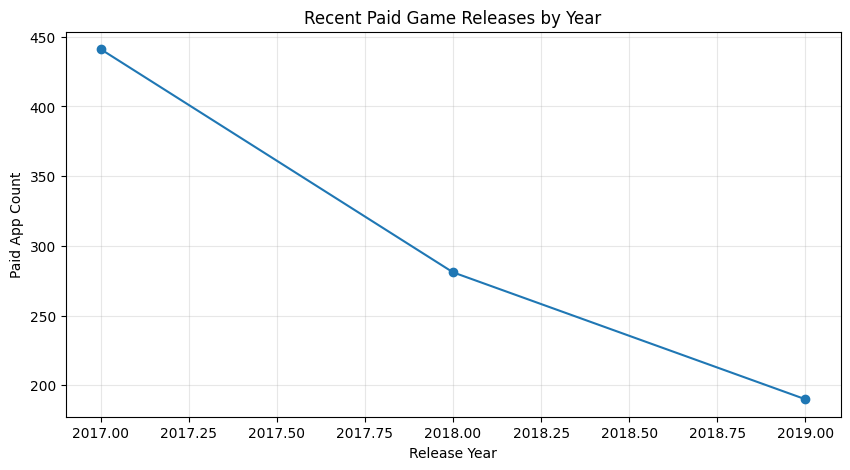


## Nhận xét

Trong giai đoạn **2017–2019**, số lượng game Paid ra mắt được dùng để đánh giá mức độ active của thị trường Paid gần đây.

Năm gần nhất trong dataset là **2019**, có **190** game Paid ra mắt.

Điều này quan trọng vì nếu thị trường Paid game có ít app mới hoặc traction thấp, stakeholder cần thận trọng hơn trong việc chọn genre, định giá và positioning.


In [8]:
yearly_market = (
    recent_paid.groupby("release_year")
    .agg(
        paid_app_count=("app_id", "nunique"),
        median_price=("price_usd", "median"),
        total_rating_count=("rating_count", "sum")
    )
    .reset_index()
)

yearly_rated = (
    rated_recent_paid.groupby("release_year")
    .agg(
        rated_paid_app_count=("app_id", "nunique"),
        median_rating_velocity=("rating_velocity", "median"),
        median_weighted_rating=("weighted_rating", "median"),
        median_paid_revenue_proxy=("paid_revenue_proxy", "median")
    )
    .reset_index()
)

yearly_market = yearly_market.merge(yearly_rated, on="release_year", how="left")

display(yearly_market)

plt.figure(figsize=(10, 5))
plt.plot(yearly_market["release_year"], yearly_market["paid_app_count"], marker="o")
plt.title("Recent Paid Game Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Paid App Count")
plt.grid(True, alpha=0.3)
plt.show()

last_year = yearly_market.sort_values("release_year").iloc[-1]

display(Markdown(f"""
## Nhận xét

Trong giai đoạn **{recent_start_year}–{latest_year}**, số lượng game Paid ra mắt được dùng để đánh giá mức độ active của thị trường Paid gần đây.

Năm gần nhất trong dataset là **{int(last_year["release_year"])}**, có **{int(last_year["paid_app_count"]):,}** game Paid ra mắt.

Điều này quan trọng vì nếu thị trường Paid game có ít app mới hoặc traction thấp, stakeholder cần thận trọng hơn trong việc chọn genre, định giá và positioning.
"""))

# 11. Output 2 — Price Range Analysis

## Business Question

Mức giá nào có tín hiệu tốt trong giai đoạn gần nhất?

## Metric

Theo từng `price_group`, tính:

- `app_count`
- `median_price`
- `avg_weighted_rating`
- `median_rating_count`
- `median_rating_velocity`
- `median_paid_revenue_proxy`

## Business Meaning

Với Paid game, giá không chỉ là doanh thu kỳ vọng mà còn là rào cản tải game.

Price range tốt nên có:

- Weighted rating ổn.
- Rating count không quá thấp.
- Paid revenue proxy tương đối tốt.
- Không chỉ dựa vào giá cao.

,price_group,rated_app_count,median_price,avg_weighted_rating,median_rating_count,median_rating_velocity,median_paid_revenue_proxy,price_range_score
3,$3.99-$4.99,78,4.99,4.118004,43.5,21.500000,187.530,85.768183
4,$5-$9.99,33,8.99,4.100722,47.0,20.000000,422.530,82.913529
2,$2.99,35,2.99,4.120697,25.0,19.000000,74.750,69.118784
1,$1.99,31,1.99,4.091457,33.0,20.000000,65.670,61.900317
5,$10+,4,24.99,4.065464,29.5,14.750000,1666.205,60.644372
0,$0.99,52,0.99,4.052714,13.5,5.166667,13.365,0.000000


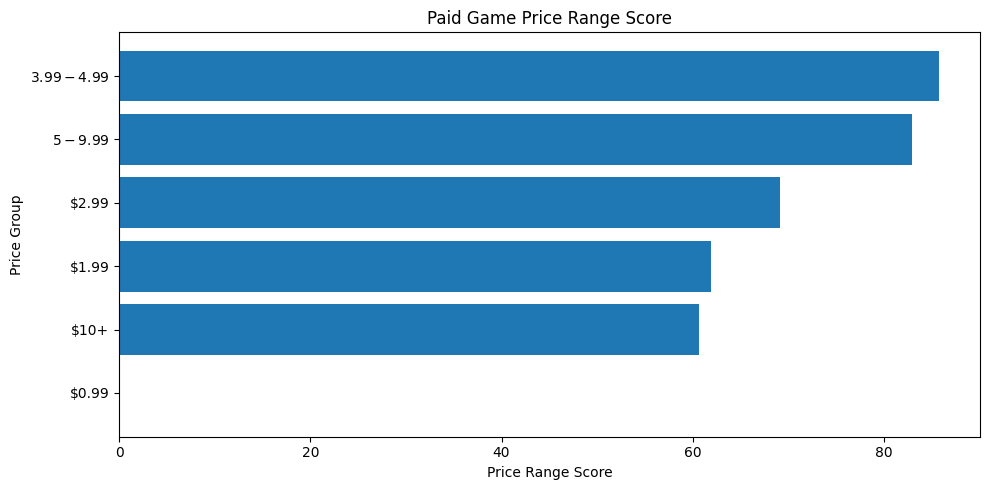


## Nhận xét

Price range có tín hiệu tốt nhất theo score là **$3.99-$4.99** với score **85.8**.

Nhóm giá này nổi bật vì kết hợp được weighted rating, rating count, rating velocity và paid revenue proxy.

Về mặt business, stakeholder nên xem đây là price range tham khảo ban đầu, không phải mức giá cố định. Cần kết hợp thêm genre, positioning và competitor benchmark trước khi chốt giá launch.


In [9]:
price_order = ["$0.99", "$1.99", "$2.99", "$3.99-$4.99", "$5-$9.99", "$10+"]

rated_recent_paid["price_group"] = pd.Categorical(
    rated_recent_paid["price_group"],
    categories=price_order,
    ordered=True
)

price_summary = (
    rated_recent_paid.groupby("price_group", observed=False)
    .agg(
        rated_app_count=("app_id", "nunique"),
        median_price=("price_usd", "median"),
        avg_weighted_rating=("weighted_rating", "mean"),
        median_rating_count=("rating_count", "median"),
        median_rating_velocity=("rating_velocity", "median"),
        median_paid_revenue_proxy=("paid_revenue_proxy", "median"),
        total_paid_revenue_proxy=("paid_revenue_proxy", "sum")
    )
    .reset_index()
)

# Loại price group không có app
price_summary = price_summary[price_summary["rated_app_count"] > 0].copy()

# Tạo price_range_score để hỗ trợ chọn mức giá
def minmax_norm(s):
    s = s.astype(float).replace([np.inf, -np.inf], np.nan).fillna(0)

    if s.max() == s.min():
        return pd.Series(0.5, index=s.index)

    return (s - s.min()) / (s.max() - s.min())

price_summary["log_median_rating_count"] = np.log1p(price_summary["median_rating_count"])
price_summary["log_median_revenue_proxy"] = np.log1p(price_summary["median_paid_revenue_proxy"])

price_summary["weighted_rating_norm"] = minmax_norm(price_summary["avg_weighted_rating"])
price_summary["rating_count_norm"] = minmax_norm(price_summary["log_median_rating_count"])
price_summary["revenue_proxy_norm"] = minmax_norm(price_summary["log_median_revenue_proxy"])
price_summary["rating_velocity_norm"] = minmax_norm(np.log1p(price_summary["median_rating_velocity"]))

price_summary["price_range_score"] = (
    0.30 * price_summary["weighted_rating_norm"]
    + 0.25 * price_summary["rating_count_norm"]
    + 0.25 * price_summary["revenue_proxy_norm"]
    + 0.20 * price_summary["rating_velocity_norm"]
) * 100

price_summary = price_summary.sort_values("price_range_score", ascending=False)

display(
    price_summary[
        [
            "price_group",
            "rated_app_count",
            "median_price",
            "avg_weighted_rating",
            "median_rating_count",
            "median_rating_velocity",
            "median_paid_revenue_proxy",
            "price_range_score"
        ]
    ]
)

plt.figure(figsize=(10, 5))
plot_data = price_summary.sort_values("price_range_score", ascending=True)

plt.barh(plot_data["price_group"].astype(str), plot_data["price_range_score"])
plt.title("Paid Game Price Range Score")
plt.xlabel("Price Range Score")
plt.ylabel("Price Group")
plt.tight_layout()
plt.show()

best_price_group = price_summary.iloc[0]

display(Markdown(f"""
## Nhận xét

Price range có tín hiệu tốt nhất theo score là **{best_price_group["price_group"]}** với score **{best_price_group["price_range_score"]:.1f}**.

Nhóm giá này nổi bật vì kết hợp được weighted rating, rating count, rating velocity và paid revenue proxy.

Về mặt business, stakeholder nên xem đây là price range tham khảo ban đầu, không phải mức giá cố định. Cần kết hợp thêm genre, positioning và competitor benchmark trước khi chốt giá launch.
"""))

# 12. Output 3 — Genre Freshness Rate

## Business Question

Genre nào còn active gần đây trong nhóm Paid game?

## Metric

`genre_freshness_rate = recent_paid_apps / total_paid_apps`

Ý nghĩa:

- Freshness cao: genre vẫn có nhiều Paid game mới ra mắt.
- Freshness thấp: genre có thể ít còn được studio mới tham gia.
- Freshness cao + traction tốt: genre đáng nghiên cứu sâu.
- Freshness cao + app count lớn: thị trường active nhưng có thể cạnh tranh mạnh.

In [10]:
genre_freshness = (
    paid_data.groupby("game_genre")
    .agg(
        total_paid_apps=("app_id", "nunique"),
        recent_paid_apps_all=("release_year", lambda x: x.ge(recent_start_year).sum())
    )
    .reset_index()
)

genre_freshness["genre_freshness_rate"] = (
    genre_freshness["recent_paid_apps_all"] / genre_freshness["total_paid_apps"]
)

genre_freshness = genre_freshness.sort_values("genre_freshness_rate", ascending=False)

display(genre_freshness.head(15))

top_fresh_genre = genre_freshness.iloc[0]

display(Markdown(f"""
## Nhận xét

Genre có freshness rate cao nhất là **{top_fresh_genre["game_genre"]}** với freshness rate khoảng **{top_fresh_genre["genre_freshness_rate"]:.1%}**.

Điều này cho thấy genre này vẫn có Paid game mới ra mắt trong giai đoạn gần nhất.

Tuy nhiên, freshness cao không đồng nghĩa chắc chắn nên chọn. Với Paid game, cần kết hợp thêm willingness-to-pay proxy, weighted rating, rating count và price range.
"""))

,game_genre,total_paid_apps,recent_paid_apps_all,genre_freshness_rate
6,Family,44,22,0.500000
12,Sports,30,14,0.466667
5,Casual,93,42,0.451613
15,Word,17,7,0.411765
11,Simulation,215,82,0.381395
0,Action,119,41,0.344538
7,Music,3,1,0.333333
1,Adventure,60,20,0.333333
13,Strategy,1424,467,0.327949
8,Puzzle,310,100,0.322581



## Nhận xét

Genre có freshness rate cao nhất là **Family** với freshness rate khoảng **50.0%**.

Điều này cho thấy genre này vẫn có Paid game mới ra mắt trong giai đoạn gần nhất.

Tuy nhiên, freshness cao không đồng nghĩa chắc chắn nên chọn. Với Paid game, cần kết hợp thêm willingness-to-pay proxy, weighted rating, rating count và price range.


# 13. Output 4 — Genre Attractiveness for Paid Game

## Business Question

Nếu ra mắt game Paid, nên ưu tiên genre nào?

## Metric

Tạo `paid_genre_attractiveness_score`.

Đây là analyst-defined score, không phải machine learning model.

Score được tính từ:

| Component | Weight | Ý nghĩa |
|---|---:|---|
| avg_weighted_rating | 30% | Chất lượng rating đáng tin |
| median_paid_revenue_proxy | 25% | Proxy cho willingness-to-pay/commercial potential |
| median_rating_velocity | 20% | Tốc độ tạo traction |
| total_rating_count | 15% | Market traction |
| genre_freshness_rate | 10% | Genre còn active gần đây |

Lưu ý:

- `paid_revenue_proxy = price_usd * rating_count` không phải doanh thu thật.
- Chỉ dùng để so sánh tương đối giữa genre trong dataset.

,game_genre,recent_paid_apps,rated_recent_paid_apps,avg_weighted_rating,median_price,median_rating_count,total_rating_count,median_rating_velocity,median_paid_revenue_proxy,genre_freshness_rate,paid_genre_attractiveness_score
0,Action,41,13.0,4.275963,3.99,109.0,42478.0,79.000000,394.210,0.344538,93.799066
9,Simulation,82,26.0,4.132805,3.99,56.0,33604.0,25.500000,184.965,0.381395,62.953014
11,Strategy,467,117.0,4.086179,2.99,30.0,69705.0,18.500000,125.370,0.327949,50.780543
8,Role Playing,28,17.0,4.115388,4.99,63.0,7056.0,32.000000,258.390,0.269231,46.761368
7,Puzzle,100,19.0,4.105701,1.99,16.0,5449.0,5.500000,32.890,0.322581,15.941719
2,Board,68,18.0,4.020016,3.49,13.0,10588.0,4.583333,51.860,0.286920,10.010520


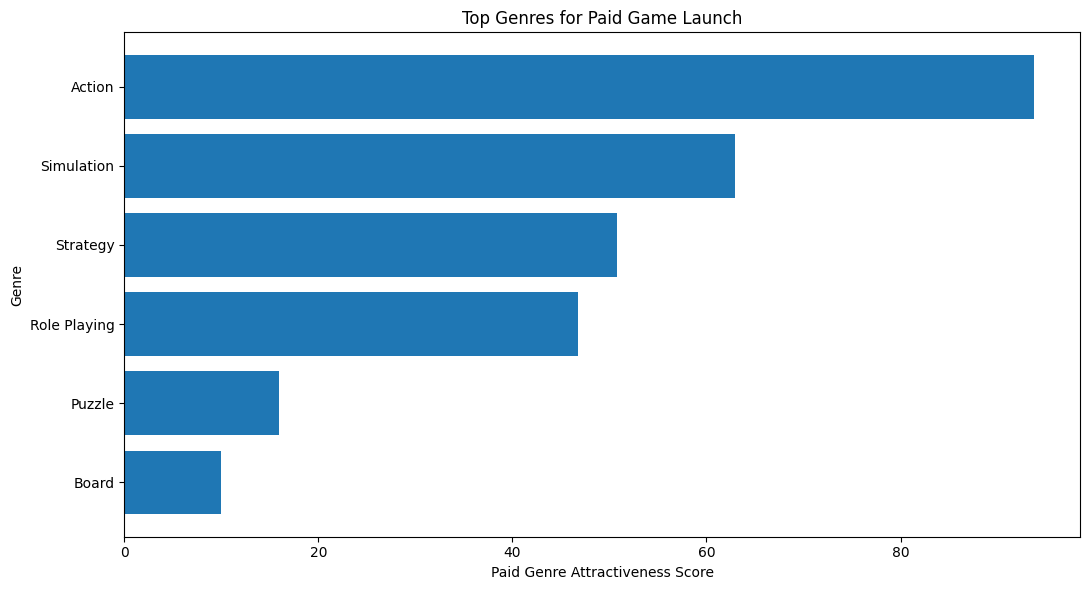


## Nhận xét

Genre đứng đầu theo Paid Genre Attractiveness Score là **Action** với score **93.8**.

Genre này nổi bật vì kết hợp được weighted rating, paid revenue proxy, rating velocity và freshness rate.

Về mặt business, đây là genre nên được ưu tiên nghiên cứu sâu nếu stakeholder muốn chọn hướng Paid có tín hiệu willingness-to-pay tốt hơn.


In [11]:
# Recent app count = competition proxy
genre_recent_count = (
    recent_paid.groupby("game_genre")
    .agg(
        recent_paid_apps=("app_id", "nunique")
    )
    .reset_index()
)

# Rated recent apps = traction/quality analysis base
genre_recent_quality = (
    rated_recent_paid.groupby("game_genre")
    .agg(
        rated_recent_paid_apps=("app_id", "nunique"),
        avg_weighted_rating=("weighted_rating", "mean"),
        median_rating_count=("rating_count", "median"),
        total_rating_count=("rating_count", "sum"),
        median_rating_velocity=("rating_velocity", "median"),
        median_price=("price_usd", "median"),
        median_paid_revenue_proxy=("paid_revenue_proxy", "median"),
        total_paid_revenue_proxy=("paid_revenue_proxy", "sum"),
        median_language_count=("language_count", "median")
    )
    .reset_index()
)

genre_score_base = (
    genre_recent_count
    .merge(genre_recent_quality, on="game_genre", how="left")
    .merge(genre_freshness, on="game_genre", how="left")
)

# Chỉ lấy genre có đủ số game có rating để tránh sample quá nhỏ
min_rated_apps = 10

genre_score = genre_score_base[
    genre_score_base["rated_recent_paid_apps"].fillna(0) >= min_rated_apps
].copy()

# Nếu data quá ít, giảm ngưỡng để không bị rỗng
if genre_score.empty:
    min_rated_apps = 3
    genre_score = genre_score_base[
        genre_score_base["rated_recent_paid_apps"].fillna(0) >= min_rated_apps
    ].copy()

# Normalize skewed metrics
genre_score["log_total_rating_count"] = np.log1p(genre_score["total_rating_count"].fillna(0))
genre_score["log_median_rating_velocity"] = np.log1p(genre_score["median_rating_velocity"].fillna(0))
genre_score["log_median_revenue_proxy"] = np.log1p(genre_score["median_paid_revenue_proxy"].fillna(0))

genre_score["weighted_rating_norm"] = minmax_norm(genre_score["avg_weighted_rating"])
genre_score["revenue_proxy_norm"] = minmax_norm(genre_score["log_median_revenue_proxy"])
genre_score["rating_velocity_norm"] = minmax_norm(genre_score["log_median_rating_velocity"])
genre_score["total_rating_count_norm"] = minmax_norm(genre_score["log_total_rating_count"])
genre_score["freshness_rate_norm"] = minmax_norm(genre_score["genre_freshness_rate"])

genre_score["paid_genre_attractiveness_score"] = (
    0.30 * genre_score["weighted_rating_norm"]
    + 0.25 * genre_score["revenue_proxy_norm"]
    + 0.20 * genre_score["rating_velocity_norm"]
    + 0.15 * genre_score["total_rating_count_norm"]
    + 0.10 * genre_score["freshness_rate_norm"]
) * 100

genre_score = genre_score.sort_values(
    "paid_genre_attractiveness_score",
    ascending=False
)

genre_attractiveness_table = genre_score[
    [
        "game_genre",
        "recent_paid_apps",
        "rated_recent_paid_apps",
        "avg_weighted_rating",
        "median_price",
        "median_rating_count",
        "total_rating_count",
        "median_rating_velocity",
        "median_paid_revenue_proxy",
        "genre_freshness_rate",
        "paid_genre_attractiveness_score"
    ]
].head(15)

display(genre_attractiveness_table)

plt.figure(figsize=(11, 6))
plot_data = genre_attractiveness_table.sort_values(
    "paid_genre_attractiveness_score",
    ascending=True
)

plt.barh(
    plot_data["game_genre"],
    plot_data["paid_genre_attractiveness_score"]
)
plt.title("Top Genres for Paid Game Launch")
plt.xlabel("Paid Genre Attractiveness Score")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

best_genre = genre_score.iloc[0]

display(Markdown(f"""
## Nhận xét

Genre đứng đầu theo Paid Genre Attractiveness Score là **{best_genre["game_genre"]}** với score **{best_genre["paid_genre_attractiveness_score"]:.1f}**.

Genre này nổi bật vì kết hợp được weighted rating, paid revenue proxy, rating velocity và freshness rate.

Về mặt business, đây là genre nên được ưu tiên nghiên cứu sâu nếu stakeholder muốn chọn hướng Paid có tín hiệu willingness-to-pay tốt hơn.
"""))

# 14. Output 5 — Paid Genre Opportunity Matrix

## Business Question

Genre nào vừa có paid potential tốt vừa không quá crowded?

## Logic

Không phải genre score cao là chọn ngay.

Stakeholder cần hiểu genre đó thuộc nhóm nào:

| Nhóm | Ý nghĩa |
|---|---|
| Priority opportunity | Paid potential cao, cạnh tranh chưa quá cao |
| Big market / high competition | Paid potential cao nhưng cạnh tranh mạnh |
| Crowded / weak paid signal | Nhiều app nhưng paid signal chưa tốt |
| Niche / validate carefully | Quy mô nhỏ hơn, cần test kỹ |

## Metric

- Competition proxy: `recent_paid_apps`
- Paid potential proxy: `median_paid_revenue_proxy`

,game_genre,recent_paid_apps,median_paid_revenue_proxy,median_rating_velocity,avg_weighted_rating,genre_freshness_rate,paid_genre_attractiveness_score,opportunity_type
0,Action,41,394.210,79.000000,4.275963,0.344538,93.799066,Priority opportunity
9,Simulation,82,184.965,25.500000,4.132805,0.381395,62.953014,Niche / validate carefully
11,Strategy,467,125.370,18.500000,4.086179,0.327949,50.780543,Crowded / weak paid signal
8,Role Playing,28,258.390,32.000000,4.115388,0.269231,46.761368,Priority opportunity
7,Puzzle,100,32.890,5.500000,4.105701,0.322581,15.941719,Crowded / weak paid signal
2,Board,68,51.860,4.583333,4.020016,0.286920,10.010520,Niche / validate carefully


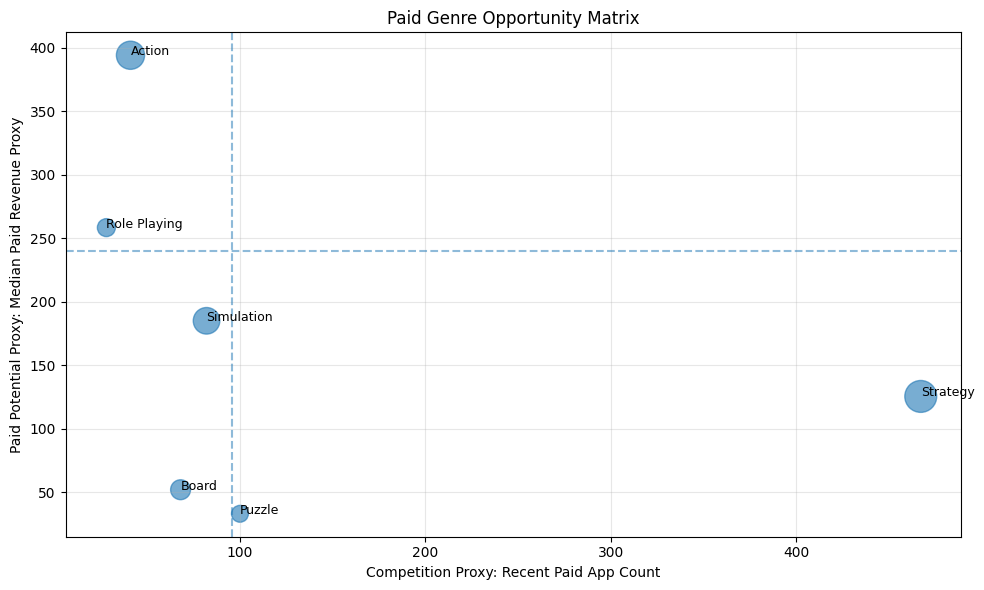


## Nhận xét

Nhóm genre ưu tiên theo ma trận cơ hội là: **Action, Role Playing**.

Nếu nguồn lực launch có giới hạn, stakeholder nên ưu tiên genre có paid potential tốt nhưng cạnh tranh chưa quá crowded.

Nếu chọn genre thuộc nhóm Big Market / High Competition, studio cần chuẩn bị sản phẩm chất lượng cao, review tốt, thương hiệu/marketing mạnh và positioning rõ ràng.


In [12]:
competition_cut = genre_score["recent_paid_apps"].quantile(0.75)
paid_signal_cut = genre_score["median_paid_revenue_proxy"].quantile(0.75)

def classify_paid_opportunity(row):
    if row["median_paid_revenue_proxy"] >= paid_signal_cut and row["recent_paid_apps"] < competition_cut:
        return "Priority opportunity"
    elif row["median_paid_revenue_proxy"] >= paid_signal_cut and row["recent_paid_apps"] >= competition_cut:
        return "Big market / high competition"
    elif row["median_paid_revenue_proxy"] < paid_signal_cut and row["recent_paid_apps"] >= competition_cut:
        return "Crowded / weak paid signal"
    else:
        return "Niche / validate carefully"

genre_score["opportunity_type"] = genre_score.apply(classify_paid_opportunity, axis=1)

genre_opportunity_table = genre_score[
    [
        "game_genre",
        "recent_paid_apps",
        "median_paid_revenue_proxy",
        "median_rating_velocity",
        "avg_weighted_rating",
        "genre_freshness_rate",
        "paid_genre_attractiveness_score",
        "opportunity_type"
    ]
].sort_values("paid_genre_attractiveness_score", ascending=False)

display(genre_opportunity_table)

plt.figure(figsize=(10, 6))

plt.scatter(
    genre_score["recent_paid_apps"],
    genre_score["median_paid_revenue_proxy"],
    s=np.sqrt(genre_score["total_rating_count"].clip(lower=1)) * 2,
    alpha=0.6
)

for _, row in genre_score.head(10).iterrows():
    plt.text(
        row["recent_paid_apps"],
        row["median_paid_revenue_proxy"],
        row["game_genre"],
        fontsize=9
    )

plt.axvline(competition_cut, linestyle="--", alpha=0.5)
plt.axhline(paid_signal_cut, linestyle="--", alpha=0.5)

plt.title("Paid Genre Opportunity Matrix")
plt.xlabel("Competition Proxy: Recent Paid App Count")
plt.ylabel("Paid Potential Proxy: Median Paid Revenue Proxy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

priority_genres = genre_opportunity_table[
    genre_opportunity_table["opportunity_type"].eq("Priority opportunity")
]

if len(priority_genres) > 0:
    priority_text = ", ".join(priority_genres["game_genre"].head(3).tolist())
else:
    priority_text = "Không có genre nào rõ ràng thuộc nhóm Priority opportunity"

display(Markdown(f"""
## Nhận xét

Nhóm genre ưu tiên theo ma trận cơ hội là: **{priority_text}**.

Nếu nguồn lực launch có giới hạn, stakeholder nên ưu tiên genre có paid potential tốt nhưng cạnh tranh chưa quá crowded.

Nếu chọn genre thuộc nhóm Big Market / High Competition, studio cần chuẩn bị sản phẩm chất lượng cao, review tốt, thương hiệu/marketing mạnh và positioning rõ ràng.
"""))

# 15. Output 6 — Top Paid Benchmark Games

## Business Question

Paid game nào nên dùng để benchmark?

## Metric

Tạo `paid_success_score`.

Đây là analyst-defined score, gồm:

| Component | Weight | Ý nghĩa |
|---|---:|---|
| weighted_rating | 30% | Chất lượng đáng tin |
| paid_revenue_proxy | 30% | Proxy cho commercial potential |
| rating_velocity | 20% | Tốc độ tạo traction |
| rating_count | 10% | Market traction |
| language_count | 10% | Localization/global reach |

Chỉ ranking các game có rating count > 0 để tránh game chưa có traction.

,name,developer,game_genre,release_year,price_usd,price_group,avg_rating,rating_count,weighted_rating,rating_velocity,paid_revenue_proxy,language_count,paid_success_score
8668,Bloons TD 6,Ninja Kiwi,Strategy,2018,4.99,$3.99-$4.99,5.0,46634.0,4.991193,23317.000000,232703.66,1,90.000000
12016,Kingdom Rush Vengeance,Ironhide S.A.,Action,2018,4.99,$3.99-$4.99,5.0,19336.0,4.979022,9668.000000,96486.64,9,86.878442
9924,Game Dev Tycoon,Greenheart Games Pty. Ltd.,Simulation,2017,4.99,$3.99-$4.99,5.0,12383.0,4.967628,4127.666667,61791.17,16,85.235529
7262,Iron Marines,Ironhide S.A.,Action,2017,4.99,$3.99-$4.99,5.0,20527.0,4.980215,6842.333333,102429.73,5,85.090394
15352,Rebel Inc.,Ndemic Creations,Simulation,2018,1.99,$1.99,5.0,17384.0,4.976722,8692.000000,34594.16,1,80.981203
5504,Through the Ages,Czech Games Edition,Strategy,2017,9.99,$5-$9.99,5.0,3032.0,4.879884,1010.666667,30289.68,1,71.671406
9625,Clue: The Classic Mystery Game,Marmalade Game Studio,Board,2017,3.99,$3.99-$4.99,4.5,10241.0,4.480730,3413.666667,40861.59,6,68.923105
15345,Exception;,Kunpo,Puzzle,2018,2.99,$2.99,5.0,2536.0,4.859716,1268.000000,7582.64,2,67.897722
13833,Escapists 2: Pocket Breakout,Team17 Software Ltd,Strategy,2019,6.99,$5-$9.99,4.5,2351.0,4.425822,2351.000000,16433.49,6,62.602755
12338,Evertale,ZigZaGame Inc.,Strategy,2019,0.99,$0.99,4.5,4067.0,4.454203,4067.000000,4026.33,8,61.734727


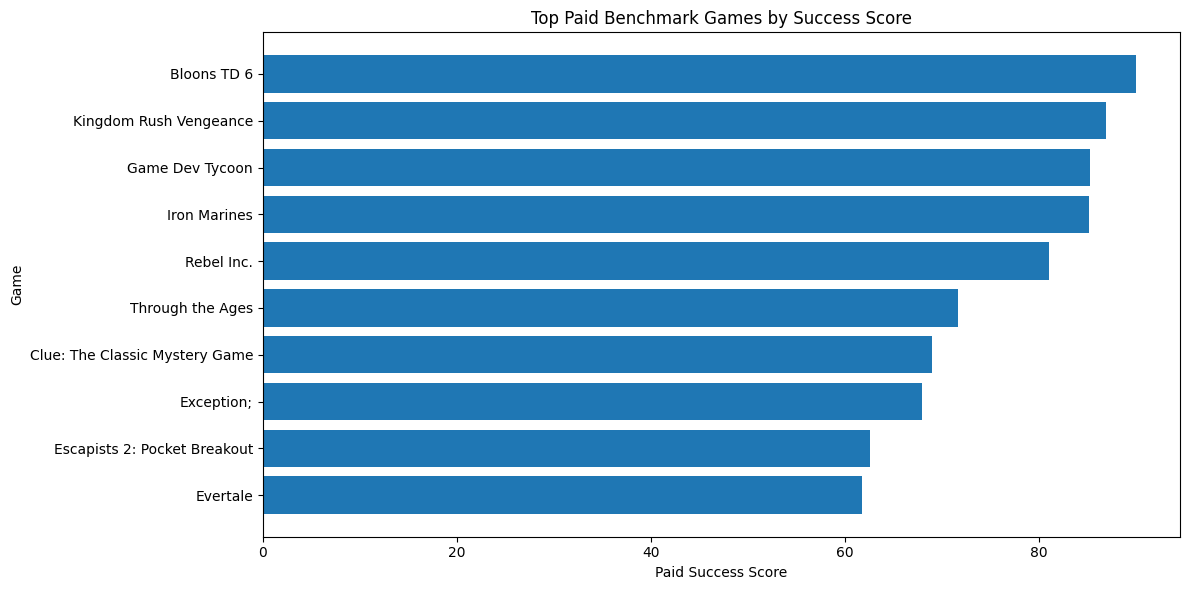


## Nhận xét

Game benchmark tốt nhất theo Paid Success Score là **Bloons TD 6** của **Ninja Kiwi**.

Game này đáng benchmark vì không chỉ có weighted rating tốt, mà còn có rating count, rating velocity và paid revenue proxy tương đối mạnh.

Về mặt business, stakeholder có thể học từ game này về premium positioning, price point, genre fit và localization footprint.


In [13]:
score_base = rated_recent_paid.copy()

score_base["log_rating_count"] = np.log1p(score_base["rating_count"].fillna(0))
score_base["log_rating_velocity"] = np.log1p(score_base["rating_velocity"].fillna(0))
score_base["log_paid_revenue_proxy"] = np.log1p(score_base["paid_revenue_proxy"].fillna(0))

score_base["weighted_rating_norm"] = minmax_norm(score_base["weighted_rating"])
score_base["revenue_proxy_norm"] = minmax_norm(score_base["log_paid_revenue_proxy"])
score_base["rating_velocity_norm"] = minmax_norm(score_base["log_rating_velocity"])
score_base["rating_count_norm"] = minmax_norm(score_base["log_rating_count"])
score_base["language_count_norm"] = minmax_norm(score_base["language_count"])

score_base["paid_success_score"] = (
    0.30 * score_base["weighted_rating_norm"]
    + 0.30 * score_base["revenue_proxy_norm"]
    + 0.20 * score_base["rating_velocity_norm"]
    + 0.10 * score_base["rating_count_norm"]
    + 0.10 * score_base["language_count_norm"]
) * 100

top_paid_games = (
    score_base.sort_values("paid_success_score", ascending=False)
    [
        [
            "name",
            "developer",
            "game_genre",
            "release_year",
            "price_usd",
            "price_group",
            "avg_rating",
            "rating_count",
            "weighted_rating",
            "rating_velocity",
            "paid_revenue_proxy",
            "language_count",
            "paid_success_score"
        ]
    ]
    .head(20)
)

display(top_paid_games)

plt.figure(figsize=(12, 6))
plot_data = top_paid_games.head(10).sort_values("paid_success_score", ascending=True)

plt.barh(plot_data["name"], plot_data["paid_success_score"])
plt.title("Top Paid Benchmark Games by Success Score")
plt.xlabel("Paid Success Score")
plt.ylabel("Game")
plt.tight_layout()
plt.show()

best_game = top_paid_games.iloc[0]

display(Markdown(f"""
## Nhận xét

Game benchmark tốt nhất theo Paid Success Score là **{best_game["name"]}** của **{best_game["developer"]}**.

Game này đáng benchmark vì không chỉ có weighted rating tốt, mà còn có rating count, rating velocity và paid revenue proxy tương đối mạnh.

Về mặt business, stakeholder có thể học từ game này về premium positioning, price point, genre fit và localization footprint.
"""))

# 16. Output 7 — Localization Strategy for Paid Games

## Business Question

Localization nên làm rộng hay chọn lọc với Paid game?

## Logic

Với Paid game, localization có thể giúp mở rộng thị trường, nhưng chi phí localization cần được cân nhắc kỹ hơn vì người dùng phải trả tiền trước.

Ta phân tích:

- Nhóm game có bao nhiêu ngôn ngữ.
- Nhóm nào có weighted rating tốt hơn.
- Nhóm nào có paid revenue proxy tốt hơn.
- Các ngôn ngữ phổ biến trong nhóm high-paid-signal games.

## Business Interpretation

- Premium/niche/story/offline game: có thể chọn localization theo thị trường mục tiêu.
- Game có thương hiệu mạnh hoặc genre global: có thể mở rộng localization hơn.
- Không nên localize quá rộng nếu chưa chứng minh được willingness-to-pay.

,language_group,rated_app_count,avg_weighted_rating,median_rating_count,median_rating_velocity,median_paid_revenue_proxy,total_paid_revenue_proxy
0,1 language,143,4.071701,22.0,12.000000,87.780,364514.31
2,2-5 languages,35,4.097055,25.0,14.333333,57.710,120374.56
3,6-10 languages,40,4.172284,132.0,46.666667,441.865,199340.84
1,11+ languages,15,4.136608,72.0,38.500000,422.530,67762.77


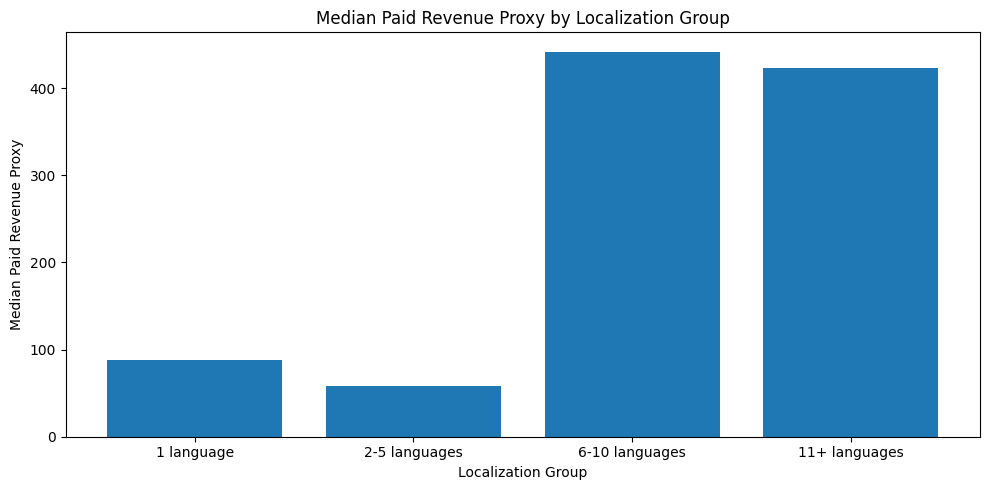


## Nhận xét

Nhóm localization có median paid revenue proxy cao nhất là **6-10 languages**.

Điều này không có nghĩa cứ thêm nhiều ngôn ngữ là Paid game sẽ thành công. Đây chỉ là pattern quan sát được trong nhóm Paid game có rating.

Về mặt business, localization nên chọn lọc theo thị trường mục tiêu và price positioning, không nên mở rộng quá nhiều nếu chưa có bằng chứng willingness-to-pay.


In [14]:
def language_group(n):
    if n <= 1:
        return "1 language"
    elif n <= 5:
        return "2-5 languages"
    elif n <= 10:
        return "6-10 languages"
    else:
        return "11+ languages"

rated_recent_paid["language_group"] = rated_recent_paid["language_count"].apply(language_group)

localization_summary = (
    rated_recent_paid.groupby("language_group", observed=False)
    .agg(
        rated_app_count=("app_id", "nunique"),
        avg_weighted_rating=("weighted_rating", "mean"),
        median_rating_count=("rating_count", "median"),
        median_rating_velocity=("rating_velocity", "median"),
        median_paid_revenue_proxy=("paid_revenue_proxy", "median"),
        total_paid_revenue_proxy=("paid_revenue_proxy", "sum")
    )
    .reset_index()
)

language_order = ["1 language", "2-5 languages", "6-10 languages", "11+ languages"]

localization_summary["language_group"] = pd.Categorical(
    localization_summary["language_group"],
    categories=language_order,
    ordered=True
)

localization_summary = localization_summary.sort_values("language_group")

display(localization_summary)

plt.figure(figsize=(10, 5))
plt.bar(
    localization_summary["language_group"].astype(str),
    localization_summary["median_paid_revenue_proxy"]
)
plt.title("Median Paid Revenue Proxy by Localization Group")
plt.xlabel("Localization Group")
plt.ylabel("Median Paid Revenue Proxy")
plt.tight_layout()
plt.show()

best_lang_group = localization_summary.sort_values(
    "median_paid_revenue_proxy",
    ascending=False
).iloc[0]

display(Markdown(f"""
## Nhận xét

Nhóm localization có median paid revenue proxy cao nhất là **{best_lang_group["language_group"]}**.

Điều này không có nghĩa cứ thêm nhiều ngôn ngữ là Paid game sẽ thành công. Đây chỉ là pattern quan sát được trong nhóm Paid game có rating.

Về mặt business, localization nên chọn lọc theo thị trường mục tiêu và price positioning, không nên mở rộng quá nhiều nếu chưa có bằng chứng willingness-to-pay.
"""))

# 17. Output 8 — Top Languages Among High Paid-Signal Games

## Business Question

Nếu launch Paid game, nên ưu tiên ngôn ngữ nào ở phase đầu?

## Logic

Lấy nhóm game có `paid_success_score` nằm trong top 10% để xem các Paid game tín hiệu mạnh thường hỗ trợ ngôn ngữ nào.

Lưu ý:

Đây là pattern mô tả, không phải quan hệ nhân quả.

,language,high_paid_signal_game_count
0,EN,24
5,DE,14
7,FR,13
6,ES,12
1,JA,10
3,RU,10
4,ZH,9
2,KO,9
8,IT,8
14,PT,4


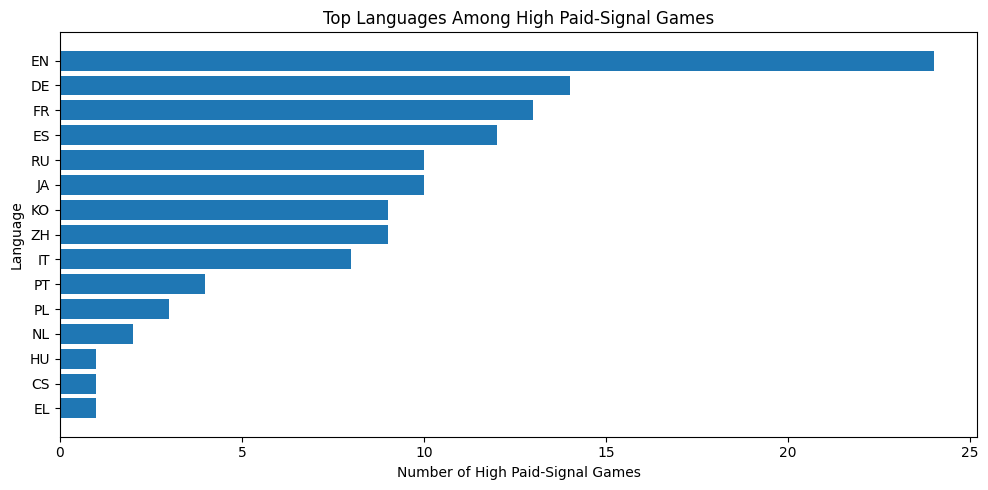


## Nhận xét

Các ngôn ngữ xuất hiện nhiều nhất trong nhóm high-paid-signal Paid games là: **EN, DE, FR, ES, JA**.

Về mặt business, đây là nhóm ngôn ngữ nên cân nhắc cho localization phase 1.

Tuy nhiên, lựa chọn cuối cùng còn phụ thuộc vào thị trường mục tiêu, mức giá, genre và ngân sách localization.


In [15]:
high_paid_signal_cut = score_base["paid_success_score"].quantile(0.90)

high_paid_signal_games = score_base[
    score_base["paid_success_score"] >= high_paid_signal_cut
].copy()

language_counter = {}

for langs in high_paid_signal_games["language_list"]:
    for lang in langs:
        language_counter[lang] = language_counter.get(lang, 0) + 1

top_languages_high_paid_signal = (
    pd.DataFrame(
        language_counter.items(),
        columns=["language", "high_paid_signal_game_count"]
    )
    .sort_values("high_paid_signal_game_count", ascending=False)
    .head(15)
)

display(top_languages_high_paid_signal)

plt.figure(figsize=(10, 5))
plot_data = top_languages_high_paid_signal.sort_values(
    "high_paid_signal_game_count",
    ascending=True
)

plt.barh(plot_data["language"], plot_data["high_paid_signal_game_count"])
plt.title("Top Languages Among High Paid-Signal Games")
plt.xlabel("Number of High Paid-Signal Games")
plt.ylabel("Language")
plt.tight_layout()
plt.show()

top_language_list = ", ".join(top_languages_high_paid_signal["language"].head(5).tolist())

display(Markdown(f"""
## Nhận xét

Các ngôn ngữ xuất hiện nhiều nhất trong nhóm high-paid-signal Paid games là: **{top_language_list}**.

Về mặt business, đây là nhóm ngôn ngữ nên cân nhắc cho localization phase 1.

Tuy nhiên, lựa chọn cuối cùng còn phụ thuộc vào thị trường mục tiêu, mức giá, genre và ngân sách localization.
"""))

# 18. Output 9 — Developer Benchmark

## Business Question

Developer nào nên benchmark nếu studio muốn launch game Paid?

## Metric

Tạo `developer_benchmark_score`.

Score gồm:

| Component | Weight | Ý nghĩa |
|---|---:|---|
| avg_weighted_rating | 30% | Chất lượng đáng tin |
| total_paid_revenue_proxy | 30% | Proxy cho commercial potential |
| median_rating_velocity | 20% | Tốc độ tạo traction |
| median_price | 10% | Price positioning |
| median_language_count | 10% | Localization/global reach |

Chỉ lấy developer có ít nhất 2 Paid game có rating trong giai đoạn gần nhất để tránh benchmark từ sample quá nhỏ.

In [16]:
developer_summary_base = (
    rated_recent_paid.groupby("developer")
    .agg(
        rated_paid_app_count=("app_id", "nunique"),
        avg_weighted_rating=("weighted_rating", "mean"),
        total_rating_count=("rating_count", "sum"),
        median_rating_count=("rating_count", "median"),
        median_rating_velocity=("rating_velocity", "median"),
        median_price=("price_usd", "median"),
        total_paid_revenue_proxy=("paid_revenue_proxy", "sum"),
        median_paid_revenue_proxy=("paid_revenue_proxy", "median"),
        median_language_count=("language_count", "median"),
        main_genre=("game_genre", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan)
    )
    .reset_index()
)

developer_summary = developer_summary_base[
    developer_summary_base["rated_paid_app_count"] >= 2
].copy()

# Nếu data quá ít, fallback lấy developer có ít nhất 1 app
if developer_summary.empty:
    developer_summary = developer_summary_base[
        developer_summary_base["rated_paid_app_count"] >= 1
    ].copy()

developer_summary["log_total_revenue_proxy"] = np.log1p(
    developer_summary["total_paid_revenue_proxy"].fillna(0)
)

developer_summary["log_median_rating_velocity"] = np.log1p(
    developer_summary["median_rating_velocity"].fillna(0)
)

developer_summary["weighted_rating_norm"] = minmax_norm(
    developer_summary["avg_weighted_rating"]
)

developer_summary["revenue_proxy_norm"] = minmax_norm(
    developer_summary["log_total_revenue_proxy"]
)

developer_summary["rating_velocity_norm"] = minmax_norm(
    developer_summary["log_median_rating_velocity"]
)

developer_summary["price_norm"] = minmax_norm(
    developer_summary["median_price"]
)

developer_summary["language_count_norm"] = minmax_norm(
    developer_summary["median_language_count"]
)

developer_summary["developer_benchmark_score"] = (
    0.30 * developer_summary["weighted_rating_norm"]
    + 0.30 * developer_summary["revenue_proxy_norm"]
    + 0.20 * developer_summary["rating_velocity_norm"]
    + 0.10 * developer_summary["price_norm"]
    + 0.10 * developer_summary["language_count_norm"]
) * 100

top_developers = (
    developer_summary.sort_values("developer_benchmark_score", ascending=False)
    [
        [
            "developer",
            "main_genre",
            "rated_paid_app_count",
            "avg_weighted_rating",
            "median_price",
            "total_rating_count",
            "median_rating_velocity",
            "total_paid_revenue_proxy",
            "median_language_count",
            "developer_benchmark_score"
        ]
    ]
    .head(20)
)

display(top_developers)

best_developer = top_developers.iloc[0]

display(Markdown(f"""
## Nhận xét

Developer đứng đầu benchmark score là **{best_developer["developer"]}**, với main genre là **{best_developer["main_genre"]}**.

Developer này đáng benchmark vì có tín hiệu tốt về quality, paid revenue proxy và traction.

Về mặt business, stakeholder nên phân tích sâu portfolio của developer này để học cách chọn genre, đặt giá, positioning và cách tạo perceived value cho Paid game.
"""))

,developer,main_genre,rated_paid_app_count,avg_weighted_rating,median_price,total_rating_count,median_rating_velocity,total_paid_revenue_proxy,median_language_count,developer_benchmark_score
74,Ironhide S.A.,Action,2,4.979618,4.99,39863.0,8255.166667,198916.37,7.0,86.648575
114,Ndemic Creations,Simulation,2,4.621124,2.49,17842.0,4422.333333,35963.58,1.0,63.051460
156,Team17 Software Ltd,Strategy,2,4.215715,5.49,2575.0,1212.833333,17327.25,7.0,51.990330
10,Acram Digital,Strategy,2,4.326574,5.99,601.0,129.250000,3696.99,10.0,47.673243
55,Feral Interactive Ltd,Simulation,3,4.263807,4.99,1482.0,212.000000,10363.18,6.0,46.347421
63,GameCoaster,Action,2,4.455840,2.49,1345.0,287.750000,3439.55,3.5,46.291545
61,GOTO Games,Strategy,2,4.007920,34.49,74.0,18.500000,3215.26,2.0,34.344852
162,U-Play Online,Simulation,2,4.007654,8.99,105.0,17.500000,943.95,11.0,30.964212
130,Plug In Digital,Strategy,3,4.090613,1.99,501.0,24.000000,2692.99,5.0,29.869016
49,EASY Inc.,Simulation,2,4.055248,0.99,802.0,226.750000,793.98,4.5,29.863099



## Nhận xét

Developer đứng đầu benchmark score là **Ironhide S.A.**, với main genre là **Action**.

Developer này đáng benchmark vì có tín hiệu tốt về quality, paid revenue proxy và traction.

Về mặt business, stakeholder nên phân tích sâu portfolio của developer này để học cách chọn genre, đặt giá, positioning và cách tạo perceived value cho Paid game.


# 19. Output 10 — Case Study: Best Benchmark Paid Game

## Business Question

Một Paid game tiêu biểu có đặc điểm gì?

## Logic

Chọn game có `paid_success_score` cao nhất trong giai đoạn gần nhất để làm case study.

Case study giúp stakeholder hiểu rõ:

- Game thuộc genre nào?
- Giá bán bao nhiêu?
- Rating có đáng tin không?
- Rating count cao không?
- Paid revenue proxy cao không?
- Hỗ trợ bao nhiêu ngôn ngữ?
- Game phù hợp với premium/niche hay brand-led strategy?

In [17]:
case_study_game = (
    score_base.sort_values("paid_success_score", ascending=False)
    .head(1)
    .copy()
)

case_study_cols = [
    "name",
    "developer",
    "game_genre",
    "release_year",
    "age_rating",
    "price_usd",
    "price_group",
    "avg_rating",
    "rating_count",
    "weighted_rating",
    "game_age_years",
    "rating_velocity",
    "paid_revenue_proxy",
    "language_count",
    "languages",
    "size_mb",
    "paid_success_score"
]

display(case_study_game[case_study_cols])

case = case_study_game.iloc[0]

display(Markdown(f"""
## Case Study Summary

Game tiêu biểu được chọn là **{case["name"]}** của **{case["developer"]}**.

- Genre: **{case["game_genre"]}**
- Release year: **{int(case["release_year"])}**
- Price: **${case["price_usd"]:.2f}**
- Price group: **{case["price_group"]}**
- Average rating: **{case["avg_rating"]:.2f}**
- Weighted rating: **{case["weighted_rating"]:.2f}**
- Rating count: **{case["rating_count"]:,.0f}**
- Rating velocity: **{case["rating_velocity"]:,.0f} ratings/year**
- Paid revenue proxy: **{case["paid_revenue_proxy"]:,.0f}**
- Language count: **{int(case["language_count"])}**
- Paid success score: **{case["paid_success_score"]:.1f}**

Về mặt business, đây là game nên được dùng để benchmark vì nó có tín hiệu tốt về quality, paid traction và price-market fit.
"""))

,name,developer,game_genre,release_year,age_rating,price_usd,price_group,avg_rating,rating_count,weighted_rating,game_age_years,rating_velocity,paid_revenue_proxy,language_count,languages,size_mb,paid_success_score
8668,Bloons TD 6,Ninja Kiwi,Strategy,2018,9+,4.99,$3.99-$4.99,5.0,46634.0,4.991193,2,23317.0,232703.66,1,EN,156.305664,90.0



## Case Study Summary

Game tiêu biểu được chọn là **Bloons TD 6** của **Ninja Kiwi**.

- Genre: **Strategy**
- Release year: **2018**
- Price: **$4.99**
- Price group: **$3.99-$4.99**
- Average rating: **5.00**
- Weighted rating: **4.99**
- Rating count: **46,634**
- Rating velocity: **23,317 ratings/year**
- Paid revenue proxy: **232,704**
- Language count: **1**
- Paid success score: **90.0**

Về mặt business, đây là game nên được dùng để benchmark vì nó có tín hiệu tốt về quality, paid traction và price-market fit.


# 20. Final Insight & Recommendation

Phần này tổng hợp các output chính để stakeholder ra quyết định.

Recommendation phải gắn với hành động kinh doanh, không chỉ mô tả số liệu.

In [18]:
top_3_genres = genre_score.head(3)[
    [
        "game_genre",
        "recent_paid_apps",
        "rated_recent_paid_apps",
        "median_price",
        "avg_weighted_rating",
        "median_paid_revenue_proxy",
        "median_rating_velocity",
        "genre_freshness_rate",
        "paid_genre_attractiveness_score",
        "opportunity_type"
    ]
]

top_5_games = top_paid_games.head(5)
top_5_developers = top_developers.head(5)
top_5_languages = top_languages_high_paid_signal.head(5)
top_price_group = price_summary.head(3)[
    [
        "price_group",
        "rated_app_count",
        "median_price",
        "avg_weighted_rating",
        "median_rating_count",
        "median_paid_revenue_proxy",
        "price_range_score"
    ]
]

display(Markdown("## Top 3 Genre Candidates"))
display(top_3_genres)

display(Markdown("## Top 3 Price Range Candidates"))
display(top_price_group)

display(Markdown("## Top 5 Benchmark Paid Games"))
display(top_5_games)

display(Markdown("## Top 5 Benchmark Developers"))
display(top_5_developers)

display(Markdown("## Top 5 Languages for Localization Phase 1"))
display(top_5_languages)

best_genre = top_3_genres.iloc[0]
best_price = top_price_group.iloc[0]
best_game = top_5_games.iloc[0]
best_developer = top_5_developers.iloc[0]
phase_1_languages = ", ".join(top_5_languages["language"].tolist())

display(Markdown(f"""
# Executive Recommendation

## 1. Genre Priority

Genre nên ưu tiên nghiên cứu sâu là **{best_genre["game_genre"]}**.

Lý do:

- Paid Genre Attractiveness Score cao nhất: **{best_genre["paid_genre_attractiveness_score"]:.1f}**
- Median price: **${best_genre["median_price"]:.2f}**
- Average weighted rating: **{best_genre["avg_weighted_rating"]:.2f}**
- Median paid revenue proxy: **{best_genre["median_paid_revenue_proxy"]:,.0f}**
- Median rating velocity: **{best_genre["median_rating_velocity"]:,.0f}**
- Freshness rate: **{best_genre["genre_freshness_rate"]:.1%}**
- Opportunity type: **{best_genre["opportunity_type"]}**

Điều này cho thấy genre này có tín hiệu tốt về quality, willingness-to-pay proxy và mức độ active gần đây.

## 2. Price Range Recommendation

Price range nên tham khảo là **{best_price["price_group"]}**.

Lý do:

- Price range score: **{best_price["price_range_score"]:.1f}**
- Median price: **${best_price["median_price"]:.2f}**
- Average weighted rating: **{best_price["avg_weighted_rating"]:.2f}**
- Median rating count: **{best_price["median_rating_count"]:,.0f}**
- Median paid revenue proxy: **{best_price["median_paid_revenue_proxy"]:,.0f}**

Không nên lấy giá trung bình toàn bộ 2008–2019 để recommend vì hành vi trả tiền và mặt bằng giá đã thay đổi theo thời gian.

## 3. Benchmark Strategy

Game nên benchmark đầu tiên là **{best_game["name"]}** của **{best_game["developer"]}**.

Developer nên benchmark là **{best_developer["developer"]}**.

Không nên benchmark chỉ dựa trên average rating. Nên benchmark những game/developer có:

- Weighted rating tốt.
- Rating count đủ lớn.
- Paid revenue proxy tốt.
- Price range tương đồng với chiến lược launch.
- Positioning rõ ràng.

## 4. Localization Strategy

Không nên localization quá rộng ngay từ đầu.

Phase 1 nên ưu tiên các ngôn ngữ xuất hiện nhiều trong nhóm high-paid-signal games:

**{phase_1_languages}**

Sau khi game có tín hiệu paid traction thật, mới mở rộng thêm ngôn ngữ ở Phase 2.

## 5. Launch Strategy

Nếu studio muốn launch theo hướng **premium/niche/story/offline**:

- Cần nhấn mạnh chất lượng sản phẩm.
- Cần review tốt ngay từ đầu.
- Giá launch phải hợp lý với perceived value.
- Nên chọn genre có weighted rating tốt và paid revenue proxy ổn.

Nếu studio muốn launch theo hướng **paid + thương hiệu mạnh**:

- Cần bổ sung thêm dữ liệu về brand strength, IP, cộng đồng và marketing.
- Dataset hiện tại chưa đủ để chứng minh sức mạnh thương hiệu.
- Nên benchmark developer/game có price cao nhưng vẫn giữ rating count tốt.

# 2–3 Priority Actions for Stakeholder

1. **Ưu tiên validate genre {best_genre["game_genre"]}** bằng competitor review, gameplay benchmark và willingness-to-pay survey.
2. **Test price range {best_price["price_group"]}** bằng survey, landing page test hoặc soft-launch pricing test.
3. **Benchmark top Paid games/developers** trong bảng trên để học về positioning, perceived value, localization và launch messaging.

# Important Limitation

Các recommendation trên dựa trên proxy metrics từ App Store rating data.

Dataset chưa có actual sales, revenue, conversion rate, refund rate, retention, DAU/MAU, marketing spend và lịch sử thay đổi giá.

Vì vậy, đây là định hướng phân tích để hỗ trợ quyết định ban đầu, không phải kết luận tuyệt đối về khả năng thành công thương mại.
"""))

## Top 3 Genre Candidates

,game_genre,recent_paid_apps,rated_recent_paid_apps,median_price,avg_weighted_rating,median_paid_revenue_proxy,median_rating_velocity,genre_freshness_rate,paid_genre_attractiveness_score,opportunity_type
0,Action,41,13.0,3.99,4.275963,394.210,79.0,0.344538,93.799066,Priority opportunity
9,Simulation,82,26.0,3.99,4.132805,184.965,25.5,0.381395,62.953014,Niche / validate carefully
11,Strategy,467,117.0,2.99,4.086179,125.370,18.5,0.327949,50.780543,Crowded / weak paid signal


## Top 3 Price Range Candidates

,price_group,rated_app_count,median_price,avg_weighted_rating,median_rating_count,median_paid_revenue_proxy,price_range_score
3,$3.99-$4.99,78,4.99,4.118004,43.5,187.53,85.768183
4,$5-$9.99,33,8.99,4.100722,47.0,422.53,82.913529
2,$2.99,35,2.99,4.120697,25.0,74.75,69.118784


## Top 5 Benchmark Paid Games

...

## Top 5 Benchmark Developers

,developer,main_genre,rated_paid_app_count,avg_weighted_rating,median_price,total_rating_count,median_rating_velocity,total_paid_revenue_proxy,median_language_count,developer_benchmark_score
74,Ironhide S.A.,Action,2,4.979618,4.99,39863.0,8255.166667,198916.37,7.0,86.648575
114,Ndemic Creations,Simulation,2,4.621124,2.49,17842.0,4422.333333,35963.58,1.0,63.051460
156,Team17 Software Ltd,Strategy,2,4.215715,5.49,2575.0,1212.833333,17327.25,7.0,51.990330
10,Acram Digital,Strategy,2,4.326574,5.99,601.0,129.250000,3696.99,10.0,47.673243
55,Feral Interactive Ltd,Simulation,3,4.263807,4.99,1482.0,212.000000,10363.18,6.0,46.347421


## Top 5 Languages for Localization Phase 1

,language,high_paid_signal_game_count
0,EN,24
5,DE,14
7,FR,13
6,ES,12
1,JA,10



# Executive Recommendation

## 1. Genre Priority

Genre nên ưu tiên nghiên cứu sâu là **Action**.

Lý do:

- Paid Genre Attractiveness Score cao nhất: **93.8**
- Median price: **$3.99**
- Average weighted rating: **4.28**
- Median paid revenue proxy: **394**
- Median rating velocity: **79**
- Freshness rate: **34.5%**
- Opportunity type: **Priority opportunity**

Điều này cho thấy genre này có tín hiệu tốt về quality, willingness-to-pay proxy và mức độ active gần đây.

## 2. Price Range Recommendation

Price range nên tham khảo là **$3.99-$4.99**.

Lý do:

- Price range score: **85.8**
- Median price: **$4.99**
- Average weighted rating: **4.12**
- Median rating count: **44**
- Median paid revenue proxy: **188**

Không nên lấy giá trung bình toàn bộ 2008–2019 để recommend vì hành vi trả tiền và mặt bằng giá đã thay đổi theo thời gian.

## 3. Benchmark Strategy

Game nên benchmark đầu tiên là **Bloons TD 6** của **Ninja Kiwi**.

Developer nên benchmark là **Ironhide S.A.**.

Không nên benchmark chỉ dựa trên average rating. Nên benchmark những game/developer có:

- Weighted rating tốt.
- Rating count đủ lớn.
- Paid revenue proxy tốt.
- Price range tương đồng với chiến lược launch.
- Positioning rõ ràng.

## 4. Localization Strategy

Không nên localization quá rộng ngay từ đầu.

Phase 1 nên ưu tiên các ngôn ngữ xuất hiện nhiều trong nhóm high-paid-signal games:

**EN, DE, FR, ES, JA**

Sau khi game có tín hiệu paid traction thật, mới mở rộng thêm ngôn ngữ ở Phase 2.

## 5. Launch Strategy

Nếu studio muốn launch theo hướng **premium/niche/story/offline**:

- Cần nhấn mạnh chất lượng sản phẩm.
- Cần review tốt ngay từ đầu.
- Giá launch phải hợp lý với perceived value.
- Nên chọn genre có weighted rating tốt và paid revenue proxy ổn.

Nếu studio muốn launch theo hướng **paid + thương hiệu mạnh**:

- Cần bổ sung thêm dữ liệu về brand strength, IP, cộng đồng và marketing.
- Dataset hiện tại chưa đủ để chứng minh sức mạnh thương hiệu.
- Nên benchmark developer/game có price cao nhưng vẫn giữ rating count tốt.

# 2–3 Priority Actions for Stakeholder

1. **Ưu tiên validate genre Action** bằng competitor review, gameplay benchmark và willingness-to-pay survey.
2. **Test price range $3.99-$4.99** bằng survey, landing page test hoặc soft-launch pricing test.
3. **Benchmark top Paid games/developers** trong bảng trên để học về positioning, perceived value, localization và launch messaging.

# Important Limitation

Các recommendation trên dựa trên proxy metrics từ App Store rating data.

Dataset chưa có actual sales, revenue, conversion rate, refund rate, retention, DAU/MAU, marketing spend và lịch sử thay đổi giá.

Vì vậy, đây là định hướng phân tích để hỗ trợ quyết định ban đầu, không phải kết luận tuyệt đối về khả năng thành công thương mại.
